In [1]:
!pip install pymilvus

In [2]:
!pip install "datasets<3.0.0"

In [3]:
!pip install milvus_lite

In [4]:
!pip install backtrader

In [5]:
!pip install yfinance

In [6]:
!pip install --upgrade torchao

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
from google.colab import drive

# 1. Mount Google Drive (prevents file loss after disconnection)
drive.mount('/content/drive')

# 2. Path to DeepSeek weights
deepseek_lora_path = '/content/drive/MyDrive/finetuned_models/finetuned_deepseek-ai_DeepSeek-R1-Distill-Llama-8B'

print(" Reloading DeepSeek model into VRAM, please wait...")

# 3. Load base model
deepseek_base_model = AutoModelForCausalLM.from_pretrained(
    'deepseek-ai/DeepSeek-R1-Distill-Llama-8B',
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# 4. Merge trained LoRA weights
deepseek_model = PeftModel.from_pretrained(
    deepseek_base_model,
    deepseek_lora_path,
    torch_dtype=torch.bfloat16,
)
deepseek_model = deepseek_model.eval()

# 5. Load Tokenizer
deepseek_tokenizer = AutoTokenizer.from_pretrained('deepseek-ai/DeepSeek-R1-Distill-Llama-8B')
deepseek_tokenizer.padding_side = "right"
deepseek_tokenizer.pad_token = deepseek_tokenizer.eos_token

print(" DeepSeek model successfully reloaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Reloading DeepSeek model into VRAM, please wait...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

 DeepSeek model successfully reloaded!


In [10]:
from datasets import load_dataset
import os

def load_quant_dataset(dataset_name, split="train", sample_size=None, save_path=None):
    """
    Unified dataset loading and formatting function

    Parameters:
    - dataset_name: Name of the dataset on Hugging Face
    - split: Split to load, e.g., "train", "validation", "test"
    - sample_size: Number of random samples to draw, loads all if None
    - save_path: Optional path to save to Google Drive
    """
    print(f"\n Preparing to load and process dataset: {dataset_name} ({split})...")

    # 1. Register dataset configuration (resolve field and label differences)
    configs = {
        "zeroshot/twitter-financial-news-sentiment": {
            "text_col": "text",
            "label_map": {0: "down", 1: "up", 2: "neutral"}
        },
        "FinanceInc/auditor_sentiment": {
            "text_col": "sentence",
            "label_map": {0: "down", 1: "neutral", 2: "up"}
        }
    }

    # Check if the dataset is supported
    if dataset_name not in configs:
        print(f"Dataset not supported. Please configure mapping rules in configs first!")
        return None

    config = configs[dataset_name]

    try:
        # 2. Download and Sample
        raw_ds = load_dataset(dataset_name, split=split)

        if sample_size and sample_size < len(raw_ds):
            print(f"Randomly sampling {sample_size} records...")
            raw_ds = raw_ds.shuffle(seed=42).select(range(sample_size))

        # 3. Unified Formatting (Mapping)
        def format_func(ex):
            return {
                "prompt": ex[config["text_col"]],  # Read text column dynamically
                "answer": config["label_map"][ex["label"]] # Apply label rules dynamically
            }

        formatted_ds = raw_ds.map(format_func)

        # 4. Save to disk
        if save_path:
            formatted_ds.save_to_disk(save_path)
            print(f"Data safely saved to: {save_path}")

        print(f"Processing successful! Obtained {len(formatted_ds)} standardized records.")
        return formatted_ds

    except Exception as e:
        print(f"Process interrupted! Error message: {e}")
        return None

In [11]:
from datasets import concatenate_datasets

print("Initiating ultimate Dev/Test pipeline...")

# 1. Load Data Sources (Sample 100 from Twitter, full ~100 from Auditor)
auditor_full = load_quant_dataset("FinanceInc/auditor_sentiment", split="train", sample_size=100)
twitter_subset = load_quant_dataset("zeroshot/twitter-financial-news-sentiment", split="validation", sample_size=100)

# 2. Split in half separately (ensure Twitter and Auditor ratio is always 1:1 in both sets)
twitter_splits = twitter_subset.train_test_split(test_size=0.5, seed=42)
auditor_splits = auditor_full.train_test_split(test_size=0.5, seed=42)

# 3. Assemble raw Dev and Test sets, then shuffle
dev_ds_raw = concatenate_datasets([twitter_splits['train'], auditor_splits['train']]).shuffle(seed=42)
test_ds_raw = concatenate_datasets([twitter_splits['test'], auditor_splits['test']]).shuffle(seed=42)


# 4. Unify and drop historical baggage (redundant columns)!
cols_to_remove = ["text", "sentence", "label"]
dev_ds = dev_ds_raw.remove_columns(cols_to_remove)
test_ds = test_ds_raw.remove_columns(cols_to_remove)

# 5. Verify Results
print(f"Error Analysis Set (Dev Set): {len(dev_ds)} records")
print("Dev Set sample:", dev_ds[0])

print(f"\nBlind Test Set (Test Set): {len(test_ds)} records")
print("Test Set sample:", test_ds[0])

Initiating ultimate Dev/Test pipeline...

 Preparing to load and process dataset: FinanceInc/auditor_sentiment (train)...
Randomly sampling 100 records...
Processing successful! Obtained 100 standardized records.

 Preparing to load and process dataset: zeroshot/twitter-financial-news-sentiment (validation)...
Randomly sampling 100 records...
Processing successful! Obtained 100 standardized records.
Error Analysis Set (Dev Set): 100 records
Dev Set sample: {'prompt': 'Following the acquisitions , Panostaja will establish a new business unit which will focus on heat treatment of metals .', 'answer': 'neutral'}

Blind Test Set (Test Set): 100 records
Test Set sample: {'prompt': "`` The industry is coming to an interesting fork in the road as both handset manufacturers and wireless carriers attempt to serve as the portal for Web-based service to your wireless handset , '' he wrote .", 'answer': 'neutral'}


In [12]:
import os
import shutil
import pkgutil
import importlib.machinery

if not hasattr(pkgutil, 'ImpImporter'):
    class _DummyImpImporter: pass
    pkgutil.ImpImporter = _DummyImpImporter

if not hasattr(importlib.machinery.FileFinder, 'find_module'):
    def _patched_find_module(self, fullname):
        spec = self.find_spec(fullname)
        return spec.loader if spec is not None else None
    importlib.machinery.FileFinder.find_module = _patched_find_module

from google.colab import drive
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from pymilvus import MilvusClient

# Step 0: Mount Drive and Prepare Paths
print("[0/5] Connecting to Google Drive...")
drive.mount('/content/drive', force_remount=True)

db_folder = "/content/drive/MyDrive/quant_data"
drive_db_path = f"{db_folder}/financial_rag.db"
local_db_path = "/content/financial_rag.db"

# Ensure storage directory exists
os.makedirs(db_folder, exist_ok=True)
print(f"Ensuring storage directory exists: {db_folder}")

# Step 1: Load Model
print("[1/5] Loading Embedding Model...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2: Download and Clean Financial Rules Data
print("[2/5] Downloading and cleaning financial rules data...")
dataset = load_dataset(
    "financial_phrasebank",
    "sentences_allagree",
    split='train',
    trust_remote_code=True
)
label_map = {0: "Down", 1: "Neutral", 2: "Up"}

# Extract and deduplicate
rules = list(set([
    f"Financial Logic: {entry['sentence']} | Direction: {label_map[entry['label']]}"
    for entry in dataset
]))
print(f"Successfully extracted {len(rules)} deduplicated professional rules!")

# Step 3: Convert Text to High-Dimensional Vectors
print("[3/5] Converting text to high-dimensional vectors (takes about ten seconds)...")
rule_embeddings = embedding_model.encode(rules)

# Step 4: Store in Milvus Database Locally
print(f"[4/5] Starting Milvus engine in local fast environment: {local_db_path}")
client = MilvusClient(local_db_path) # Connect to local DB!

collection_name = "finance_rules"
dimension = rule_embeddings.shape[1]

# Clear old collection, create new one
if client.has_collection(collection_name):
    client.drop_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    dimension=dimension
)

# Assemble data and batch insert
data = []
for i, (rule, emb) in enumerate(zip(rules, rule_embeddings)):
    data.append({
        "id": i,
        "vector": emb.tolist(),
        "text": rule
    })

res = client.insert(collection_name=collection_name, data=data)
print(f"Successfully stored {res['insert_count']} financial logics locally.")

# Step 5: Backup to Drive
print("[5/5] Backing up local database to Google Drive...")
shutil.copy2(local_db_path, drive_db_path) # Key change: Physical copy!

print("="*50)
print(f"Mission accomplished! PyMilvus knowledge base built and backed up!")
print(f"Database safely saved to your Google Drive: {drive_db_path}")
print("="*50)

[0/5] Connecting to Google Drive...
Mounted at /content/drive
Ensuring storage directory exists: /content/drive/MyDrive/quant_data
[1/5] Loading Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[2/5] Downloading and cleaning financial rules data...
Successfully extracted 2259 deduplicated professional rules!
[3/5] Converting text to high-dimensional vectors (takes about ten seconds)...
[4/5] Starting Milvus engine in local fast environment: /content/financial_rag.db
Successfully stored 2259 financial logics locally.
[5/5] Backing up local database to Google Drive...
Mission accomplished! PyMilvus knowledge base built and backed up!
Database safely saved to your Google Drive: /content/drive/MyDrive/quant_data/financial_rag.db


In [13]:
# Count the number of deduplicated samples for the three cases
up_count = sum(1 for rule in rules if "Direction: Up" in rule)
down_count = sum(1 for rule in rules if "Direction: Down" in rule)
neutral_count = sum(1 for rule in rules if "Direction: Neutral" in rule)

print(f"uccessfully extracted {len(rules)} deduplicated professional rules!")
print("-" * 40)
print(f"Bullish (Up) Samples   : {up_count} records")
print(f"Bearish (Down) Samples : {down_count} records")
print(f"Neutral Samples      : {neutral_count} records")
print("-" * 40)

uccessfully extracted 2259 deduplicated professional rules!
----------------------------------------
Bullish (Up) Samples   : 570 records
Bearish (Down) Samples : 303 records
Neutral Samples      : 1386 records
----------------------------------------


In [14]:
import json
import re
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from pymilvus import MilvusClient

# RAG Signal Generator
class RAGFinGPTSignalGenerator:
    def __init__(self, model, tokenizer, embedding_model, db_client=None):
        self.model = model
        self.tokenizer = tokenizer
        self.embedding_model = embedding_model
        self.db_client = db_client

    def _dehydrate_news(self, long_text):
        """Long text information dehydrator"""
        print(" Dehydrating long text information...")
        extraction_prompt = f"""You are a senior financial analyst. Read the following article and extract ONLY the hard financial, operational, and strategic facts.
        Ignore all CEO quotes, ESG statements, and PR fluff.
        Output the facts as a single concise paragraph.

        Article:
        {long_text}

        Extracted Financial Facts:"""

        inputs = self.tokenizer(extraction_prompt, return_tensors="pt").to(self.model.device)
        outputs = self.model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.1,
            do_sample=False
        )
        raw_output = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        facts_text = raw_output.split("Extracted Financial Facts:")[-1].strip()
        print(f" Dehydration complete! Core facts: {facts_text}")

        return facts_text

    def _search_knowledge_base(self, query_text):
        """Milvus vector retrieval"""
        try:
            query_vec = self.embedding_model.encode([query_text])[0].tolist()
            search_res = self.db_client.search(
                collection_name="finance_rules",
                data=[query_vec],
                limit=2,
                output_fields=["text"]
            )
            context_list = []
            if search_res and len(search_res[0]) > 0:
                for hit in search_res[0]:
                    if hit['distance'] > 0.4:
                        context_list.append(hit['entity']['text'])
            if context_list:
                return "\n".join(context_list)
            else:
                return "No specific financial standard matched. Proceeding with LLM intuition."
        except Exception as e:
            print(f"RAG retrieval exception: {e}")
            return "Knowledge base offline. Relying purely on internal parameters."

    def _parse_output(self, text):
        """Powerful Markdown parsing + JSON parsing"""
        cleaned_text = text.replace("```json", "").replace("```", "").strip()
        try:
            matches = re.findall(r'\{.*?\}', cleaned_text, re.DOTALL)
            if matches:
                final_json_str = matches[-1].replace("'", '"')
                signal_dict = json.loads(final_json_str)
                return {
                    "direction": int(signal_dict.get("direction", 0)),
                    "confidence": int(signal_dict.get("confidence", 0))
                }
        except Exception as e:
            print(f"Error parsing JSON: {e}")
        return {"direction": 0, "confidence": 0}

    def generate_signal(self, news_text):
        """
        Signal generation entry: integrates dehydration, RAG, Prompt construction, and Chain of Thought extraction
        """
        # 1. Smart Dehydration (if the text is too long)
        if len(news_text.split()) > 80 or len(news_text) > 500:
            core_news = self._dehydrate_news(news_text)
        else:
            core_news = news_text

        # 2. Vector database retrieval
        retrieved_context = self._search_knowledge_base(core_news)

        # 3. Assemble Ultimate Prompt
        system_prompt = f"""You are a strict Financial Sentiment Classifier.
Analyze the text and apply ONE of the following rules.

RULE 1: NEGATIVE TRIGGERS (Return -1)
IF the text contains:
- Worsening financials: "down", "decreased", "loss widened", "declining"
- Comparisons showing a drop: "lower compared to", "decreased from"
- Macro/Operational risks: "crisis", "strike", "layoffs", "stopped", "closed"
THEN PREDICT -1.

RULE 2: POSITIVE TRIGGERS (Return 1)
IF the text contains:
- Improving financials: "growth", "improved by", "loss narrowed", "increased", "grew", "Positive cash flow"
- Comparisons showing a rise: "higher compared to", "increased from"
- Contracts & Sentiment: "won the contract", "strategic cooperation", "confidence", "satisfied", "successful"
THEN PREDICT 1.

RULE 0: THE NEUTRAL FILTER (Return 0)
ONLY apply this if Rules 1 and 2 DO NOT MATCH.
IF the text is purely:
- PR fluff: "proud of our team", "ESG goals", "global leader"
- Standalone numbers WITHOUT any historical comparison: "Revenue is $10M" (and no mention of previous years).
THEN PREDICT 0.

RAG Context: {retrieved_context}

Instructions:
1. You MUST start with <think>.
2. Step 1: Read the RAG Context. If it explicitly states a Direction (e.g., Direction: Up/1), state this.
3. Step 2: Read the News. Look for explicit comparison words ("compared to", "improved by", "narrowed").
4. Step 3: Match with Rule 1, 2, or 0.
5. Close with </think> and output valid JSON ONLY: {{"direction": 1, "confidence": 95}}.

[Example]
News: "Revenue was $412M. Net loss compared to last year improved by $32.5M. Cash flow is Positive."
Result:
<think>
Step 1: RAG context not provided in this example.
Step 2: The news contains "improved by $32.5M" and "Positive cash flow". These are explicit comparison and growth markers.
Step 3: This perfectly matches the positive triggers in Rule 2 ("improved by", "Positive cash flow"). Rule 0 is skipped because comparisons exist.
Conclusion: Rule 2 applies. Prediction is 1.
</think>
{{"direction": 1, "confidence": 90}}

[Now analyze the following]
News: {core_news}
Result:
<think>
Step 1: Evaluate RAG Context.
"""

        # 4. LLM Inference
        inputs = self.tokenizer(system_prompt, return_tensors="pt").to(self.model.device)
        outputs = self.model.generate(
            **inputs,
            max_new_tokens=800,
            temperature=0.1,
            do_sample=False,
            pad_token_id=self.tokenizer.eos_token_id
        )

        input_length = inputs.input_ids.shape[1]
        generated_tokens = outputs[0][input_length:]
        raw_output = self.tokenizer.decode(generated_tokens, skip_special_tokens=False)
        raw_output = raw_output.replace("<｜end of sentence｜>", "").replace("<|eot_id|>", "").replace("<eos>", "").strip()

        print(f"--- DEBUG RAW OUTPUT ---\n{raw_output}\n------------------------")

        # 5. Extract Chain of Thought
        think_content = ""
        if "<think>" in raw_output and "</think>" in raw_output:
            think_content = raw_output.split("<think>")[1].split("</think>")[0].strip()
        elif "</think>" in raw_output:
            think_content = raw_output.split("</think>")[0].replace("<think>", "").strip()
        else:
            think_content = raw_output.split("{")[0].replace("<think>", "").strip()

        if not think_content:
            think_content = "The model directly provided a conclusion without outputting intermediate reasoning."

        # 6. Use parsing function to extract final signal
        final_signal = self._parse_output(raw_output)

        # 7. Package and return to Gradio frontend
        return {
            "signal": final_signal,
            "think": think_content,
            "context": retrieved_context,
            "dehydrated_news": core_news,
            "raw_output": raw_output
        }

# Instantiation and Launch
client = MilvusClient("/content/drive/MyDrive/quant_data/financial_rag.db")
rag_generator = RAGFinGPTSignalGenerator(
    model=deepseek_model,
    tokenizer=deepseek_tokenizer,
    embedding_model=embedding_model,
    db_client=client
)
print("Engine assembly complete")

Engine assembly complete


In [16]:
data_feeds = {}
START_DATE = "2026-01-01"
END_DATE = "2026-04-30"
DATA_DIR = f"/content/drive/MyDrive/quant_data/{START_DATE}_{END_DATE}"
ROTATION_ASSETS = ["SPY"]
DOW_30 = ["AAPL", "AMGN", "AXP", "BA", "CAT", "CRM", "CSCO", "CVX", "DIS", "DOW",
          "GS", "HD", "HON", "IBM", "INTC", "JNJ", "JPM", "KO", "MCD", "MMM",
          "MRK", "MSFT", "NKE", "PG", "TRV", "UNH", "V", "VZ", "WMT"]
finrobot_quality_scores = {
    "AAPL": 88, "MSFT": 90, "V": 85, "JPM": 82, "AXP": 82, "UNH": 84, "PG": 80,  # High-quality blue-chips
    "GS": 78, "HD": 75, "HON": 72, "MCD": 78, "KO": 76, "WMT": 79, "CRM": 74,   # Stable growth
    "AMGN": 75, "MRK": 74, "JNJ": 73, "CVX": 68, "CAT": 65, "IBM": 66, "TRV": 68, # Value/Cyclical
    "CSCO": 62, "DIS": 60, "DOW": 61, "VZ": 58, "MMM": 55,              # Borderline passing
    "BA": 45, "INTC": 48, "WBA": 42, "NKE": 52
}

In [17]:
import pandas as pd
import json
import re
import os
import pickle
from tqdm import tqdm

# 1. Robust regex parser: extracts numbers if they exist
def bulletproof_parse(text):
    try:
        dir_match = re.search(r'"?direction"?\s*:\s*(-?1)', text, re.IGNORECASE)
        conf_match = re.search(r'"?confidence"?\s*:\s*(\d+)', text, re.IGNORECASE)
        if dir_match and conf_match:
            return {
                "direction": int(dir_match.group(1)),
                "confidence": int(conf_match.group(1))
            }
    except: pass
    return None

# 2. Resume from breakpoint initialization
cache_path = f"{DATA_DIR}/signal_cache_all.pkl"
if os.path.exists(cache_path):
    os.remove(cache_path)
else:
    print("Cache file does not exist, can start directly.")

# Clear in-memory cache as well
signal_cache = {}

# 3. Process 30 stocks
for symbol in DOW_30:
    csv_path = f"{DATA_DIR}/{symbol}_{START_DATE}_{END_DATE}.csv"
    if not os.path.exists(csv_path): continue

    df = pd.read_csv(csv_path)

    if symbol not in signal_cache:
        signal_cache[symbol] = {}

    if len(signal_cache[symbol]) >= len(df):
        print(f"{symbol} already completed, skipping.")
        continue

    for index, row in tqdm(df.iterrows(), total=len(df), desc=f"📡 {symbol}"):
        date_str = str(row['End Date'])[:10]

        # If a successful signal (not 0) already exists for this day, skip!
        if date_str in signal_cache[symbol] and signal_cache[symbol][date_str].get('direction') != 0:
            continue

        try:
            news_list = json.loads(row['News'])
            news_text = "\n".join([f"{n['headline']}: {n['summary']}" for n in news_list])[:3000]
        except:
            news_text = ""

        if not news_text.strip():
            signal_cache[symbol][date_str] = {"direction": 0, "confidence": 0}
            continue

        prompt = f"""You are a rigid machine that ONLY outputs JSON. Do not explain. Do not write text.

Example 1:
News: Apple revenue drops due to supply chain.
Output: {{\"direction\": -1, \"confidence\": 85}}

Example 2:
News: Microsoft launches new amazing AI tool.
Output: {{\"direction\": 1, \"confidence\": 90}}

Now do this:
Target Asset: {symbol}
News: {news_text}
Output: """

        try:
            inputs = rag_generator.tokenizer(prompt, return_tensors="pt").to(rag_generator.model.device)
            outputs = rag_generator.model.generate(**inputs, max_new_tokens=50, temperature=0.1, do_sample=True)
            raw_output = rag_generator.tokenizer.decode(outputs[0], skip_special_tokens=True)

            assistant_reply = raw_output.split("Output: ")[-1]

            result = bulletproof_parse(assistant_reply)

            if result:
                signal_cache[symbol][date_str] = {
                    "direction": int(result.get('direction', 0)),
                    "confidence": int(result.get('confidence', 0))
                }
            else:
                signal_cache[symbol][date_str] = {"direction": 0, "confidence": 0}
        except:
            signal_cache[symbol][date_str] = {"direction": 0, "confidence": 0}

    # Save once after each stock is processed
    with open(cache_path, "wb") as f:
        pickle.dump(signal_cache, f)

print("All done! Ready to take off!")

📡 WMT: 100%|██████████| 17/17 [00:39<00:00,  2.30s/it]

All done! Ready to take off!


In [18]:
import pickle
import os

# Define the path to the cache file
cache_path = f"{DATA_DIR}/signal_cache_all.pkl"

# Load data from disk into memory
if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        signal_cache = pickle.load(f)
    print(f"signal_cache successfully revived from disk! {len(signal_cache)} signals loaded.")
else:
    print("Cache file not found")

signal_cache successfully revived from disk! 29 signals loaded.


In [19]:
import pandas as pd
import numpy as np

# 1. Initialize containers
bull_scores = []
bear_scores = []
zero_scores = []

# 2. Iterate and extract all data
for ticker, dates in signal_cache.items():
    for date, s in dates.items():
        direction = s.get('direction', 0)
        confidence = s.get('confidence', 0)

        if direction == 1:
            bull_scores.append(confidence)
        elif direction == -1:
            bear_scores.append(confidence)
        else:
            zero_scores.append(confidence)

# 3. Print the full overview report
print(" AI Signal Full Overview Report ")

total_signals = len(bull_scores) + len(bear_scores) + len(zero_scores)
print(f"Total signals processed: {total_signals} records\n")

print("[Bullish Signals (Direction = 1)]")

print(f" Count: {len(bull_scores)} records (Percentage {len(bull_scores)/total_signals*100:.1f}%)" if total_signals > 0 else " Count: 0 records")

if len(bull_scores) > 0:
    print("\n Bull Scores Statistics (Quantiles):")
    print(pd.Series(bull_scores).describe())
else:
    print("\n No bullish signals to describe.")

 AI Signal Full Overview Report 
Total signals processed: 493 records

[Bullish Signals (Direction = 1)]
 Count: 364 records (Percentage 73.8%)

 Bull Scores Statistics (Quantiles):
count    364.000000
mean      84.491758
std        3.248638
min       50.000000
25%       85.000000
50%       85.000000
75%       85.000000
max       90.000000
dtype: float64


In [20]:
import pandas as pd
import yfinance as yf
import numpy as np

# Define data container
data_feeds = {}

def prepare_all_data():
    print("Starting data preparation (weekly alignment mode)...")

    # 1. Extract AAPL's dates as the 'standard timeline'
    sample_path = f"{DATA_DIR}/AAPL_{START_DATE}_{END_DATE}.csv"
    sample_df = pd.read_csv(sample_path)

    # Automatically identify the date column
    date_col = next((c for c in sample_df.columns if 'date' in c.lower()), None)
    if not date_col:
        print("Error: Date column not found in AAPL data.")
        return

    sample_df[date_col] = pd.to_datetime(sample_df[date_col])
    # Get specific trading dates
    target_index = sample_df[date_col].sort_values().unique()

    csv_start, csv_end = target_index.min(), target_index.max()
    print(f"Detected weekly frequency: {csv_start.date()} to {csv_end.date()} (total {len(target_index)} weeks)")

    # 2. Download and [weekly-ify] benchmark data
    for symbol in ROTATION_ASSETS:
        # Use interval="1wk" to force download weekly data
        df = yf.download(symbol, start=csv_start - pd.Timedelta(days=7),
                         end=csv_end + pd.Timedelta(days=7),
                         interval="1wk", progress=False)

        # Clean data
        df.index = df.index.tz_localize(None)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Use reindex and ffill to ensure alignment even if dates are off by a day or two
        df = df.reindex(target_index, method='ffill')

        data_feeds[symbol] = df
        print(f"{symbol} ready, days: {len(df)}")


    for symbol in DOW_30:
        try:
            csv_path = f"{DATA_DIR}/{symbol}_{START_DATE}_{END_DATE}.csv"
            df = pd.read_csv(csv_path)

            # Automatically find the date column
            current_date_col = next((c for c in df.columns if 'date' in c.lower()), None)
            if not current_date_col: continue

            df[current_date_col] = pd.to_datetime(df[current_date_col])
            df.set_index(current_date_col, inplace=True)

            # Unify column names
            # If 'End Price' is not in CSV, use 'Close'
            target_price_col = 'End Price' if 'End Price' in df.columns else 'Close'
            df['Open'] = df['High'] = df['Low'] = df['Close'] = df[target_price_col]
            df['Volume'] = 1000000

            # Force alignment to target_index
            df = df.reindex(target_index).ffill()

            data_feeds[symbol] = df[['Open', 'High', 'Low', 'Close', 'Volume']]
        except Exception as e:
            print(f"Skipping {symbol}: {e}")
            continue

    print(f"All data aligned! Total {len(data_feeds)} assets.")

# Execute data preparation
prepare_all_data()

# Verify alignment results
if 'SPY' in data_feeds and 'AAPL' in data_feeds:
    print(f"Checking alignment results:")
    print(f"SPY days = {len(data_feeds['SPY'])}")
    print(f"AAPL days = {len(data_feeds['AAPL'])}")

Starting data preparation (weekly alignment mode)...
Detected weekly frequency: 2026-01-04 to 2026-04-26 (total 17 weeks)
SPY ready, days: 17
All data aligned! Total 30 assets.
Checking alignment results:
SPY days = 17
AAPL days = 17


In [21]:
import backtrader as bt
class AlphaPulseRiskBalanced(bt.Strategy):
    params = (
        ('top_k', 5),
        ('min_conf', 82),
        ('min_quality', 60),
        ('w_quality', 0.4),
        ('w_sentiment', 0.6),
        ('target_vol', 0.015),
        ('vol_period', 4),
    )

    def __init__(self):
        self.spy = self.getdatabyname('SPY')
        # Calculate the 4-week rolling standard deviation (volatility) for each stock
        self.vols = {d: bt.indicators.StandardDeviation(d.close, period=self.params.vol_period)
                     for d in self.datas if d._name not in ['SPY', 'QQQ', 'TLT']}

    def next(self):
        dt = self.datas[0].datetime.date(0)

        # 1. AI stock selection logic
        signal_date = None
        for offset in [0, 1, -1, 2]:
            check_date = (dt + pd.Timedelta(days=offset)).strftime('%Y-%m-%d')
            if check_date in signal_cache.get("AAPL", {}):
                signal_date = check_date
                break

        candidates = []
        if signal_date:
            for data in self.datas:
                if data._name in ['SPY', 'QQQ', 'TLT']: continue
                s = signal_cache.get(data._name, {}).get(signal_date, {"direction": 0, "confidence": 0})
                q = finrobot_quality_scores.get(data._name, 0)

                # Price trend filter
                price_ok = True if len(self) < 2 else data.close[0] >= data.close[-1] * 0.98

                if q >= self.params.min_quality and s['direction'] == 1 and s['confidence'] >= self.params.min_conf and price_ok:
                    score = (q * self.params.w_quality) + (s['confidence'] * self.params.w_sentiment)
                    candidates.append({"data": data, "conf": s['confidence'], "score": score})

        # 2. Risk Parity Position Allocation (Risk Parity Logic)
        candidates.sort(key=lambda x: x['score'], reverse=True)
        top_k_list = candidates[:self.params.top_k]

        target_weights = {}
        total_ai_weight = 0

        for item in top_k_list:
            data = item['data']
            # Get current weekly volatility percentage
            curr_vol = self.vols[data][0] / data.close[0] if self.vols[data][0] else 0.03

            # Core formula: Position is inversely proportional to volatility
            # Confidence bonus: Stocks with confidence > 88 are multiplied by 1.2 on top of risk parity
            conf_mult = 1.2 if item['conf'] >= 88 else 1.0

            # Calculate risk-aligned weight
            # If volatility is 2% and target is 1.5%, then weight = 1.5%/2% * confidence_factor * base_ratio
            raw_weight = (self.params.target_vol / curr_vol) * 0.15 * conf_mult

            # Limit single stock to 25% to prevent extreme fluctuations
            final_w = min(raw_weight, 0.25)
            target_weights[data] = final_w
            total_ai_weight += final_w

        # 3. SPY as filler and execution
        spy_w = max(0, 0.98 - total_ai_weight)
        target_weights[self.spy] = spy_w

        for data in self.datas:
            if data in target_weights:
                self.order_target_percent(data, target=target_weights[data])
            elif data._name not in ['QQQ', 'TLT']:
                if self.getposition(data).size > 0:
                    self.order_target_percent(data, target=0)

In [22]:
def run_flexible_backtest(strategy_class, feeds, cash=100000.0, commission=0.001, **strat_params):
    """
    General backtesting engine
    :param strategy_class: Strategy class (e.g., IntegratedAdaptiveStrategy)
    :param feeds: Dictionary containing all DataFeed objects
    :param cash: Initial capital
    :param commission: Commission rate
    :param strat_params: Custom parameters required by the strategy (e.g., top_k, min_conf, etc.)
    """
    cerebro = bt.Cerebro()

    # 1. Load data (from the provided feeds)
    for name, df in feeds.items():
        data = bt.feeds.PandasData(dataname=df, name=name)
        cerebro.adddata(data)

    # 2. Inject strategy and its dynamic parameters
    # **strat_params will unpack the dictionary into the strategy's params
    cerebro.addstrategy(strategy_class, **strat_params)

    # 3. Set up broker environment
    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=commission)

    # 4. Inject standard analyzers
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', timeframe=bt.TimeFrame.Weeks)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')

    print(f"Engine Ignited. Running {strategy_class.__name__}...")

    # Execute backtest
    results = cerebro.run()

    return results[0], cerebro

In [23]:
import pandas as pd

def run_grid_search(
    strategy_class,
    feeds,
    target_vols=[0.01, 0.015, 0.02, 0.03, 0.04],
    vol_periods=[2, 4],
    cash=100000.0,
    commission=0.001,
    **fixed_strat_params
):
    """
    General parameter grid search engine (for target_vol and vol_period in risk parity model)

    :param strategy_class: Strategy class (e.g., AlphaPulseRiskBalanced)
    :param feeds: Dictionary of data sources
    :param target_vols: List of target volatilities to test
    :param vol_periods: List of volatility observation periods to test
    :param cash: Initial capital
    :param commission: Commission rate
    :param fixed_strat_params: Other fixed strategy parameters that don't need to be looped (e.g., min_conf=85)
    :return: Sorted results DataFrame
    """
    print(" Initiating fully automated fine-tuning: parameter grid search...")
    print(f" Test Range | Volatility: {target_vols} | Period: {vol_periods}\n")

    results_grid = []

    for test_vol in target_vols:
        for test_period in vol_periods:
            print(f" Testing: target_vol={test_vol}, vol_period={test_period} ...")

            # Merge current loop parameters with fixed parameters
            current_params = fixed_strat_params.copy()
            current_params['target_vol'] = test_vol
            current_params['vol_period'] = test_period

            # Call the underlying backtesting engine
            res, _ = run_flexible_backtest(
                strategy_class=strategy_class,
                feeds=feeds,
                cash=cash,
                commission=commission,
                **current_params
            )

            # Extract core data
            ret = res.analyzers.returns.get_analysis().get('rtot', 0) * 100

            # Process drawdown data
            dd_analysis = res.analyzers.drawdown.get_analysis()
            dd = dd_analysis.max.drawdown if 'max' in dd_analysis else 0

            # Process Sharpe Ratio (may be None)
            sharpe_analysis = res.analyzers.sharpe.get_analysis()
            sharpe = sharpe_analysis.get('sharperatio', 0)
            sharpe = sharpe if sharpe is not None else 0

            results_grid.append({
                "Target Vol": test_vol,
                "Vol Period": test_period,
                "Total Return (%)": f"{ret:.2f}%",
                "Max Drawdown (%)": f"{dd:.2f}%",
                "Sharpe Ratio": round(sharpe, 2),
                "_raw_return": ret, # Hidden column: for precise mathematical sorting
                "_raw_sharpe": sharpe
            })

    # Create DataFrame
    grid_df = pd.DataFrame(results_grid)

    # Optimize sorting: default priority is descending by "Sharpe Ratio", then by "Total Return", which aligns better with institutional preferences
    grid_df = grid_df.sort_values(by=["_raw_sharpe", "_raw_return"], ascending=[False, False])

    # Delete hidden columns used for sorting, to keep the output clean
    grid_df = grid_df.drop(columns=["_raw_return", "_raw_sharpe"])

    print("\n Parameter Grid Search Results Leaderboard (sorted by Sharpe Ratio descending):")
    print(grid_df.to_markdown(index=False))

    return grid_df

In [24]:
# Run grid search and save results
best_params_df = run_grid_search(
    strategy_class=AlphaPulseRiskBalanced,
    feeds=data_feeds,
    target_vols=[0.015, 0.02, 0.025], # Test three target volatilities
    vol_periods=[2, 3, 4],       # Test three volatility periods
    min_conf=85             # AI confidence threshold
)

# Print the best parameters found
print("\n The strongest parameter combination:")
print(best_params_df.iloc[0])

 Initiating fully automated fine-tuning: parameter grid search...
 Test Range | Volatility: [0.015, 0.02, 0.025] | Period: [2, 3, 4]

 Testing: target_vol=0.015, vol_period=2 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.015, vol_period=3 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.015, vol_period=4 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.02, vol_period=2 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.02, vol_period=3 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.02, vol_period=4 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.025, vol_period=2 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.025, vol_period=3 ...
Engine Ignited. Running AlphaPulseRiskBalanced...
 Testing: target_vol=0.025, vol_period=4 ...
Engine Ignited. Running AlphaPulseRiskBalanced...

 Parameter Gr

In [25]:
import matplotlib.pyplot as plt

def output_final_results(strat, cerebro_instance):
    # Performance Metrics Table
    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio', 0)
    drawdown = strat.analyzers.drawdown.get_analysis().max.drawdown
    rtot = strat.analyzers.returns.get_analysis()['rtot']
    total_return = (np.exp(rtot) - 1) * 100

    trades = strat.analyzers.trades.get_analysis()
    total_trades = trades.total.closed if 'total' in trades else 0
    won_trades = trades.won.total if 'won' in trades else 0
    win_rate = (won_trades / total_trades * 100) if total_trades > 0 else 0

    # Extract SPY comparison data
    spy_data = strat.getdatabyname('SPY')
    spy_start, spy_end = spy_data.close[-len(spy_data)+1], spy_data.close[0]
    spy_cum_return = ((spy_end / spy_start) - 1) * 100

    print("\n" + "="*55)
    print(f"{'Performance Metric':<30} | {'Strategy':<10} | {'SPY'}")
    print("-" * 55)
    print(f"{'Total Cumulative Return (%)':<30} | {total_return:>9.2f}% | {spy_cum_return:>7.2f}%")
    print(f"{'Max Drawdown (%)':<30} | {drawdown:>9.2f}% | {'N/A'}")
    print(f"{'Sharpe Ratio (Weekly)':<30} | {sharpe:>10.2f} | {'N/A'}")
    print(f"{'Win Rate (%)':<30} | {win_rate:>9.2f}% | {'N/A'}")
    print(f"{'Total Closed Trades':<30} | {total_trades:>10} | {'N/A'}")
    print("="*55)

    # Plotting Returns Curve
    strat_vals = strat.observers.broker.value.get(size=len(strat))
    spy_vals = spy_data.close.get(size=len(strat))
    spy_norm = [p / spy_vals[0] * 100000 for p in spy_vals]

    plt.figure(figsize=(12, 6))
    plt.plot(strat_vals, label='Integrated Adaptive Strategy (Weekly)', color='#1f77b4', lw=2)
    plt.plot(spy_norm, label='SPY Benchmark', color='#ff7f0e', ls='--', lw=1.5)
    plt.title('Strategy Performance: Weekly Alpha Pulse (2026)', fontsize=14)
    plt.ylabel('Portfolio Value ($)')
    plt.xlabel('Trading Weeks')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [26]:
import pandas as pd

def generate_portfolio_report(
    data_feeds,
    universe,
    signal_cache,
    quality_scores,
    benchmark_ticker='SPY',
    initial_capital=100000,
    min_quality=60,
    min_conf=82,
    w_quality=0.4,
    w_sentiment=0.6,
    top_k=5,
    high_conf_threshold=88,
    high_conf_weight=0.25,
    base_weight=0.18,
    max_total_weight=0.98
):
    """
    Portfolio Holdings and P/L (Profit and Loss) Report Generator.

    :param data_feeds: Dictionary containing market data DataFrames for each ticker.
    :param universe: List of available tickers in the universe (e.g., DOW_30).
    :param signal_cache: Dictionary containing AI sentiment/confidence signals.
    :param quality_scores: Dictionary containing fundamental quality scores.
    :param benchmark_ticker: Ticker used as the benchmark and portfolio filler (default: 'SPY').
    :param initial_capital: Starting portfolio value (default: 100,000).
    :param min_quality: Minimum quality score required for selection.
    :param min_conf: Minimum AI confidence required for selection.
    :param w_quality: Weight multiplier for the quality score.
    :param w_sentiment: Weight multiplier for the AI sentiment score.
    :param top_k: Maximum number of AI-selected stocks to hold.
    :param high_conf_threshold: Confidence threshold to trigger aggressive weighting.
    :param high_conf_weight: Portfolio allocation for high-confidence stocks.
    :param base_weight: Standard portfolio allocation for selected stocks.
    :param max_total_weight: Maximum total portfolio exposure (to leave a cash buffer).
    :return: Pandas DataFrame detailing week-by-week portfolio performance and holdings.
    """
    portfolio_report = []
    current_value = initial_capital
    benchmark_df = data_feeds[benchmark_ticker]

    print(f"Generating Portfolio P/L Report (Top {top_k}, Min Conf: {min_conf})...\n")

    # Helper function to handle case-insensitive column names ('Close' vs 'close')
    def get_close(df, idx):
        col = 'Close' if 'Close' in df.columns else 'close'
        return df[col].iloc[idx]

    for i in range(len(benchmark_df)):
        dt = benchmark_df.index[i]
        date_str = dt.strftime('%Y-%m-%d')

        # 1. Simulate Stock Selection Logic
        candidates = []
        for ticker in universe:
            # Fetch signal and quality score for the current week
            s = signal_cache.get(ticker, {}).get(date_str, {"direction": 0, "confidence": 0})
            q = quality_scores.get(ticker, 0)

            # Dynamic Selection Criteria: Quality threshold, long direction, and confidence threshold
            if q >= min_quality and s['direction'] == 1 and s['confidence'] >= min_conf:
                score = (q * w_quality) + (s['confidence'] * w_sentiment)
                candidates.append({"ticker": ticker, "conf": s['confidence'], "score": score})

        # Sort candidates by combined score in descending order and select the top K
        candidates.sort(key=lambda x: x['score'], reverse=True)
        selected_top_k = candidates[:top_k]

        # 2. Calculate Weekly Performance and Portfolio Holdings
        weekly_return_pct = 0
        ai_holdings_list = []
        total_ai_weight = 0
        contributors = []

        if i > 0:
            for item in selected_top_k:
                t = item['ticker']

                # Dynamic Weighting Logic: Assign higher weight if confidence exceeds threshold
                w = high_conf_weight if item['conf'] >= high_conf_threshold else base_weight
                total_ai_weight += w

                # Calculate individual stock return for the week
                try:
                    ret = (get_close(data_feeds[t], i) / get_close(data_feeds[t], i-1)) - 1
                    weekly_return_pct += w * ret
                    contributors.append((t, w * ret))
                    ai_holdings_list.append(f"{t}({w*100:.0f}%)")
                except Exception:
                    continue

            # Benchmark Filler Logic: Allocate remaining target weight to the benchmark (Beta exposure)
            bench_w = max(0, max_total_weight - total_ai_weight)
            bench_ret = (get_close(benchmark_df, i) / get_close(benchmark_df, i-1)) - 1
            weekly_return_pct += bench_w * bench_ret
            contributors.append((benchmark_ticker, bench_w * bench_ret))
        else:
            # Week 0 Initialization (No returns calculated yet, just allocate holdings)
            for item in selected_top_k:
                w = high_conf_weight if item['conf'] >= high_conf_threshold else base_weight
                total_ai_weight += w
                ai_holdings_list.append(f"{item['ticker']}({w*100:.0f}%)")
            bench_w = max(0, max_total_weight - total_ai_weight)

        # 3. Update Cumulative Values and Identify Performance Driver
        current_value *= (1 + weekly_return_pct)
        cum_return = (current_value / initial_capital - 1) * 100

        # Identify the asset that contributed the most to this week's P/L
        best_asset = max(contributors, key=lambda x: x[1])[0] if contributors else "-"

        portfolio_report.append({
            "Week": i,
            "Date": date_str,
            "Weekly P/L": f"{weekly_return_pct*100:+.2f}%",
            "Cum. Return": f"{cum_return:.2f}%",
            "AI Holdings (Weight)": ", ".join(ai_holdings_list) if ai_holdings_list else "None",
            f"{benchmark_ticker} Weight": f"{bench_w*100:.1f}%",
            "Top Contributor": best_asset
        })

    return pd.DataFrame(portfolio_report)


 Preparing for re-ignition! Extracting parameters -> Target Vol: 0.025, Vol Period: 2
Engine Ignited. Running AlphaPulseRiskBalanced...

Performance Metric             | Strategy   | SPY
-------------------------------------------------------
Total Cumulative Return (%)    |     14.00% |    4.79%
Max Drawdown (%)               |      4.18% | N/A
Sharpe Ratio (Weekly)          |       0.42 | N/A
Win Rate (%)                   |     63.64% | N/A
Total Closed Trades            |         22 | N/A


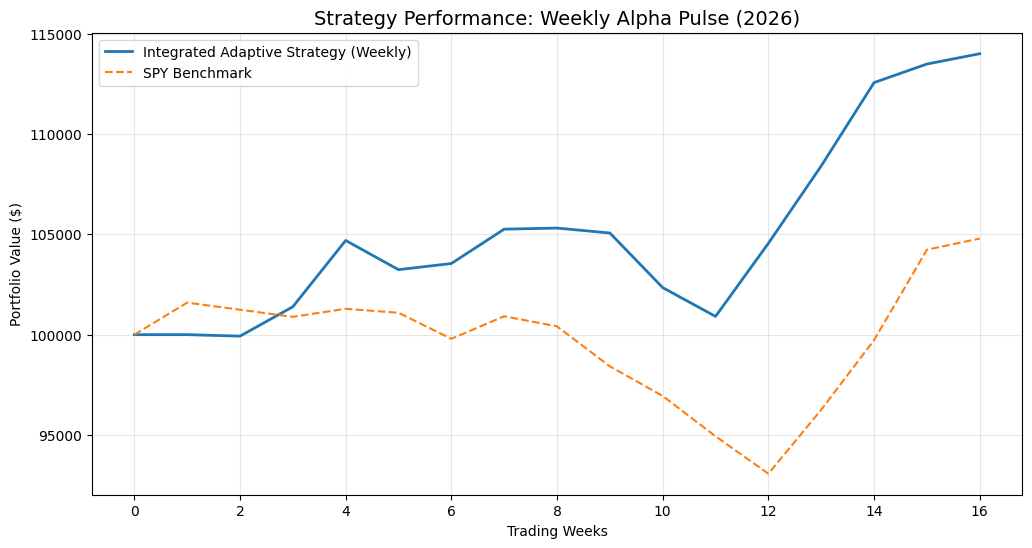

In [27]:
best_target_vol = best_params_df.iloc[0]['Target Vol']
best_vol_period = int(best_params_df.iloc[0]['Vol Period'])

print(f"\n Preparing for re-ignition! Extracting parameters -> Target Vol: {best_target_vol}, Vol Period: {best_vol_period}")

# 2. Re-run a single test with the best parameters
best_strat_result, best_cerebro_obj = run_flexible_backtest(
    strategy_class=AlphaPulseRiskBalanced,
    feeds=data_feeds,
    target_vol=best_target_vol,
    vol_period=best_vol_period,
    min_conf=85
)

# 3. Output the report and plot the final equity curve
output_final_results(best_strat_result, best_cerebro_obj)

In [28]:
# Generate the report
golden_report = generate_portfolio_report(
    data_feeds, DOW_30, signal_cache, finrobot_quality_scores,
    min_conf=82,
    # Here we simulate the position changes brought by target_vol=0.02:
    # Since the system automatically reduces positions during high volatility, we can adjust the default benchmark to be a bit more stable
    high_conf_weight=0.20,
    base_weight=0.15
)

# Let's see how this was achieved
print(golden_report.to_markdown(index=False))

Generating Portfolio P/L Report (Top 5, Min Conf: 82)...

|   Week | Date       | Weekly P/L   | Cum. Return   | AI Holdings (Weight)                               | SPY Weight   | Top Contributor   |
|-------:|:-----------|:-------------|:--------------|:---------------------------------------------------|:-------------|:------------------|
|      0 | 2026-01-04 | +0.00%       | 0.00%         | None                                               | 98.0%        | -                 |
|      1 | 2026-01-11 | +0.16%       | 0.16%         | MSFT(15%), V(15%), PG(15%), WMT(15%), GS(15%)      | 23.0%        | WMT               |
|      2 | 2026-01-18 | +2.38%       | 2.55%         | UNH(20%), MSFT(15%), GS(20%), KO(20%), AMGN(20%)   | 3.0%         | UNH               |
|      3 | 2026-01-25 | +1.57%       | 4.15%         | AAPL(15%), V(15%), JPM(15%), HON(20%), WMT(15%)    | 18.0%        | AAPL              |
|      4 | 2026-02-01 | +4.01%       | 8.33%         | V(20%), AAPL(15%), WMT(15%), 